In [1]:
import sys
sys.path.append("../")
sys.path.append("../Modules/")

import analysis

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Modules import plot_morphology

In [2]:
# sim_dir = '/home/drfrbc/Neural-Modeling/scripts/2025-03-10-13-45-checking_syn_density_tuning/tuning_Complex_Np5000'
# sim_dir = '/home/drfrbc/Neural-Modeling/scripts/2025-03-12-13-52-checking_syn_density_tuning/tuning_Complex_Np5000'
# sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-03-13-15-12-checking_syn_density_tuning/tuning_Complex_Np5000"

# sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-03-25-12-57-complex_1rhyth_50sec_fix_soma/sta_Complex_DepthPeriInh0.9500_DepthDistalInh0.9500_Np5000"

# sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-03-30-15-54-Detailed_tuning_down_dSpikes_lower_Ca_nexus/tuning_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.2420_0.2750_0.0550_0.2200_0.2310_ExcTuftDensity0.4860_0.4860_0.1080_0.5400_0.5994_Np43656"

# sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-03-30-17-28-Detailed_tuning_down_dSpikes_lower_Ca_nexus/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.2420_0.2750_0.0550_0.2200_0.2310_ExcTuftDensity0.4860_0.4860_0.1080_0.5400_0.6026_Np5000"

# sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-03-31-10-18-Running STA/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.2310_0.2750_0.0572_0.2200_0.2310_ExcTuftDensity0.4860_0.4860_0.1080_0.5400_0.6026_Np5000"

# sim_dir = '/home/drfrbc/Neural-Modeling/simulations/2025-06-09-13-55-no_clustering_30sec_sta/complex'

sim_dir = "/home/drfrbc/Neural-Modeling/simulations/2025-06-13-17-10-constant-poisson_no-delay-inh_no-clustering_fi/tuning_Complex_Np5000_amp0.0"

In [3]:
v = analysis.DataReader.read_data(sim_dir, "v")
seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))
parameters = analysis.DataReader.load_parameters(sim_dir)
adj_matrix = np.loadtxt(os.path.join(sim_dir, "adj_matrix.txt"))

--No graphics will be displayed.


In [4]:
seg_data

,section,idx_in_section_type,seg_half_seg_RA,L,length,seg,pseg,Section_L,Section_diam,Distance,...,pc_2,p1_0,p1_1,p1_2,r,dl_0,dl_1,dl_2,seg_id,sec_type_precise
0,soma,0,0.081276,23.169408,23.169408,L5PCtemplate[0].soma[0](0.5),NaN,23.169408,13.471518,0.000000,...,-50.250000,57.287731,19.065830,-50.250000,6.735759,23.124348,1.444304,0.000000,0,soma
1,dend,0,2.647135,4.840176,4.840176,L5PCtemplate[0].dend[0](0.1),L5PCtemplate[0].soma[0](0.5),24.200878,1.170000,2.420088,...,-50.027254,61.001504,21.408927,-49.444755,0.539452,4.591504,1.178928,0.805245,1,perisomatic
2,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.3),L5PCtemplate[0].dend[0](0.1),24.200878,1.170000,7.260263,...,-50.557475,64.964606,21.737526,-51.687077,0.585000,3.963102,0.328599,-2.242322,2,perisomatic
3,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.5),L5PCtemplate[0].dend[0](0.3),24.200878,1.170000,12.100439,...,-51.991813,68.301396,20.356904,-50.119401,0.585000,3.336790,-1.380622,1.567676,3,perisomatic
4,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.7),L5PCtemplate[0].dend[0](0.5),24.200878,1.170000,16.940615,...,-48.246989,70.726764,18.807201,-46.252588,0.585000,2.425368,-1.549704,3.866813,4,perisomatic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2625,axon,0,2.938245,4.615385,4.615385,L5PCtemplate[0].axon[0](0.653846),L5PCtemplate[0].axon[0](0.576923),60.000004,1.000000,39.230772,...,-50.250000,45.725559,59.882142,-50.250000,0.500000,0.000000,4.615385,0.000000,2625,axon
2626,axon,0,2.938245,4.615385,4.615385,L5PCtemplate[0].axon[0](0.730769),L5PCtemplate[0].axon[0](0.653846),60.000004,1.000000,43.846157,...,-50.250000,45.725559,64.497527,-50.250000,0.500000,0.000000,4.615385,0.000000,2626,axon
2627,axon,0,2.938245,4.615385,4.615385,L5PCtemplate[0].axon[0](0.807692),L5PCtemplate[0].axon[0](0.730769),60.000004,1.000000,48.461542,...,-50.250000,45.725559,69.112912,-50.250000,0.500000,0.000000,4.615385,0.000000,2627,axon
2628,axon,0,2.938245,4.615385,4.615385,L5PCtemplate[0].axon[0](0.884615),L5PCtemplate[0].axon[0](0.807692),60.000004,1.000000,53.076926,...,-50.250000,45.725559,73.728296,-50.250000,0.500000,0.000000,4.615385,0.000000,2628,axon


In [5]:
# post processing equivalent of cell_model.find_nexus_seg
from Modules.adjacency import find_branching_seg_with_most_branching_descendants_in_subset_y
def find_nexus_seg(seg_data, adj_matrix): # TODO: implement for reducing apic to single cable (in this case nexus is not a branching point and will need to use the seg_to_seg mapping)
    apical_segment_indices = []
    y_coords = []
    for i, seg in seg_data.iterrows():
        y_coord = seg.pc_1
        y_coords.append(y_coord)
        if 'apic' in seg.seg:
            apical_segment_indices.append(i)

    nexus_index_in_all_list, _ = find_branching_seg_with_most_branching_descendants_in_subset_y(adj_matrix, apical_segment_indices, y_coords)

    return nexus_index_in_all_list

In [6]:
# start with seg_index and then construct segments_and_data_to_plot
segments_of_interest = {
    'soma': {
        'seg_index': 0,
        },
    'nexus': {
        'seg_index': find_nexus_seg(seg_data, adj_matrix)
        }
}

In [7]:
# show target segment names
for seg_interest_type in segments_of_interest.keys():
    print(f"{seg_interest_type}: {seg_data.iloc[segments_of_interest[seg_interest_type]['seg_index']].seg}")

soma: L5PCtemplate[0].soma[0](0.5)
nexus: L5PCtemplate[0].apic[36](0.99)


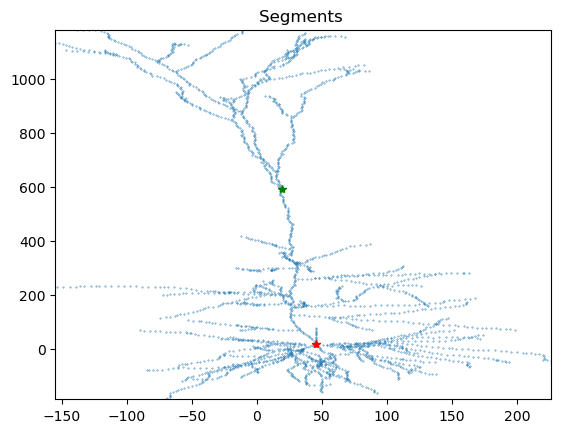

In [8]:
# show target segments
special_indices = [segments_of_interest[seg_name]['seg_index'] for seg_name in segments_of_interest.keys()]
special_colors = ['r*', 'g*', 'b*']
plot_morphology.plot_special_segments(seg_data, special_indices, special_colors, title_suffix="") # probably need to create a 3d version of this.

In [9]:
def find_relatives(seg_id, adj_matrix):
    descendant_seg_ids = np.where(adj_matrix[seg_id, :] == 1)[0]
    ascendant_seg_ids = np.where(adj_matrix[:, seg_id] == 1)[0]
    return descendant_seg_ids, ascendant_seg_ids

for seg_interest_type in segments_of_interest.keys():
    descendent_seg_ids, ascendant_seg_ids = find_relatives(segments_of_interest[seg_interest_type]['seg_index'], adj_matrix)
    segments_of_interest[seg_interest_type]['descendant_ids'] = descendent_seg_ids
    segments_of_interest[seg_interest_type]['descendant_names'] = [seg_data.iloc[seg_id].seg for seg_id in segments_of_interest[seg_interest_type]['descendant_ids']]
    segments_of_interest[seg_interest_type]['ascendant_ids'] = ascendant_seg_ids
    segments_of_interest[seg_interest_type]['ascendant_names'] = [seg_data.iloc[seg_id].seg for seg_id in segments_of_interest[seg_interest_type]['ascendant_ids']]

In [10]:
segments_of_interest

{'soma': {'seg_index': 0,
  'descendant_ids': array([   1,  128,  231,  476,  523,  770, 1005, 1014, 1070, 2617]),
  'descendant_names': ['L5PCtemplate[0].dend[0](0.1)',
   'L5PCtemplate[0].dend[7](0.0833333)',
   'L5PCtemplate[0].dend[16](0.166667)',
   'L5PCtemplate[0].dend[39](0.025)',
   'L5PCtemplate[0].dend[42](0.125)',
   'L5PCtemplate[0].dend[63](0.1)',
   'L5PCtemplate[0].dend[78](0.0555556)',
   'L5PCtemplate[0].dend[79](0.125)',
   'L5PCtemplate[0].apic[0](0.05)',
   'L5PCtemplate[0].axon[0](0.0384615)'],
  'ascendant_ids': array([], dtype=int64),
  'ascendant_names': []},
 'nexus': {'seg_index': 1547,
  'descendant_ids': array([1548, 1758]),
  'descendant_names': ['L5PCtemplate[0].apic[37](0.00892857)',
   'L5PCtemplate[0].apic[50](0.0384615)'],
  'ascendant_ids': array([1546]),
  'ascendant_names': ['L5PCtemplate[0].apic[36](0.97)']}}

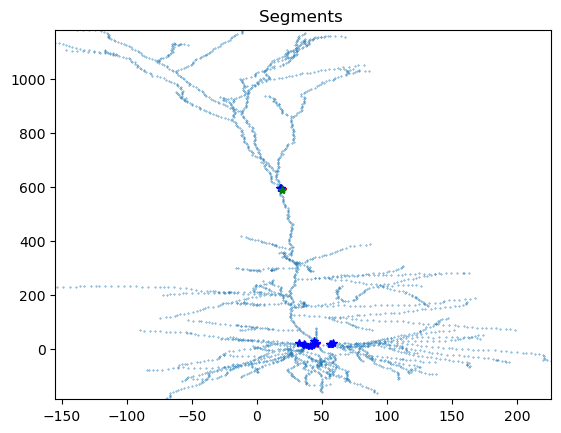

In [11]:
target_color = 'r*'
descendant_color = 'b*'
ascendant_color = 'g*'

descendent_seg_ids = []
ascendent_seg_ids = []

# Target segments
special_indices = [segments_of_interest[seg_name]['seg_index'] for seg_name in segments_of_interest.keys()]
special_colors = [target_color] * len(special_indices)

# Descendants
descendent_seg_ids = np.concatenate([segments_of_interest[seg_name]['descendant_ids'] for seg_name in segments_of_interest.keys()])
special_indices.extend(descendent_seg_ids)
special_colors.extend([descendant_color] * len(descendent_seg_ids))

# Ascendants
ascendent_seg_ids = np.concatenate([segments_of_interest[seg_name]['ascendant_ids'] for seg_name in segments_of_interest.keys()])
special_indices.extend(ascendent_seg_ids)
special_colors.extend([ascendant_color] * len(ascendent_seg_ids))

plot_morphology.plot_special_segments(seg_data, special_indices, special_colors, title_suffix="")

In [12]:
def compute_axial_currents_btwn_segments(this_seg_id, other_seg_id, v, seg_data):
            # axial current between segments from other_seg to this_seg
            # if this_seg is high and other_seg is low then current goes from this_seg to other_seg, and value would be negative.
            return -(v[this_seg_id] - v[other_seg_id]) / (seg_data.loc[this_seg_id, "seg_half_seg_RA"] + seg_data.loc[other_seg_id, "seg_half_seg_RA"])

for seg_interest_type in segments_of_interest.keys():
        this_seg_id = segments_of_interest[seg_interest_type]['seg_index']

        # ascendants (usually toward soma)
        segments_of_interest[seg_interest_type]['ascendant_currents'] = [compute_axial_currents_btwn_segments(this_seg_id, other_seg_id, v, seg_data) for other_seg_id in segments_of_interest[seg_interest_type]['ascendant_ids']]

        # descendants (usually away from soma)
        segments_of_interest[seg_interest_type]['descendant_currents'] = [compute_axial_currents_btwn_segments(this_seg_id, other_seg_id, v, seg_data) for other_seg_id in segments_of_interest[seg_interest_type]['descendant_ids']]


In [13]:
t = np.arange(0, parameters.h_tstop+parameters.h_dt, parameters.h_dt)

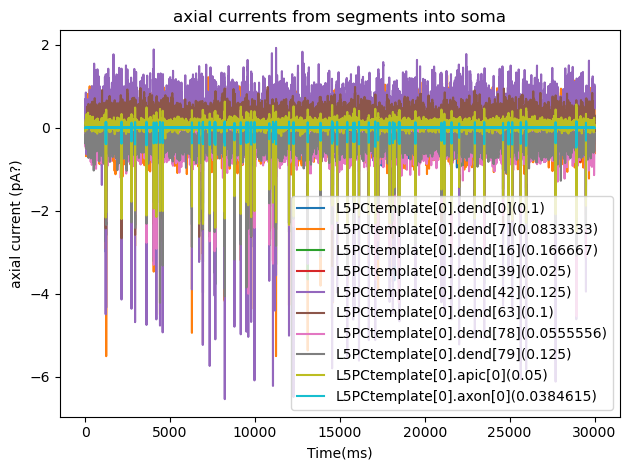

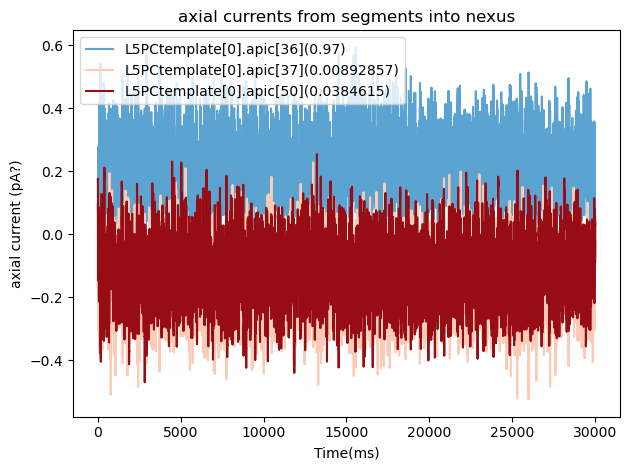

In [14]:
# plot the axial currents axial currents.

t = np.arange(0, parameters.h_tstop+parameters.h_dt, parameters.h_dt)
t=t[100:]
for seg_interest_type, seg_interest_data in segments_of_interest.items():
    # print(f"{seg_interest_type} {seg_interest_data}")
    is_soma = True if seg_interest_type == 'soma' else False
    plt.figure()
    plt.title(f"axial currents from segments into {seg_interest_type}")
    for relative_type in ['ascendant', 'descendant']:
        cmap = plt.cm.Blues if relative_type == 'ascendant' else plt.cm.Reds
        num_segments = len(seg_interest_data[f'{relative_type}_ids'])
        fractions = np.linspace(0.2, 0.9, num_segments) if num_segments > 1 else [0.55] # Generate fractions in the range [0.3, 0.8] to avoid very light colors.
        for i, seg_id in enumerate(seg_interest_data[f'{relative_type}_ids']):
            color = cmap(fractions[i])
            if is_soma:
                plt.plot(t, seg_interest_data[f'{relative_type}_currents'][i][100:], label = seg_interest_data[f'{relative_type}_names'][i]) # can make the lines clearer
                # plt.ylim([-4,2])
            else:
                plt.plot(t, seg_interest_data[f'{relative_type}_currents'][i][100:], label = seg_interest_data[f'{relative_type}_names'][i], color=color)
    # plt.xlim(48000,50000)
    plt.xlabel('Time(ms)')
    plt.ylabel('axial current (pA?)')
    plt.legend()
    plt.tight_layout()
    plt.show()

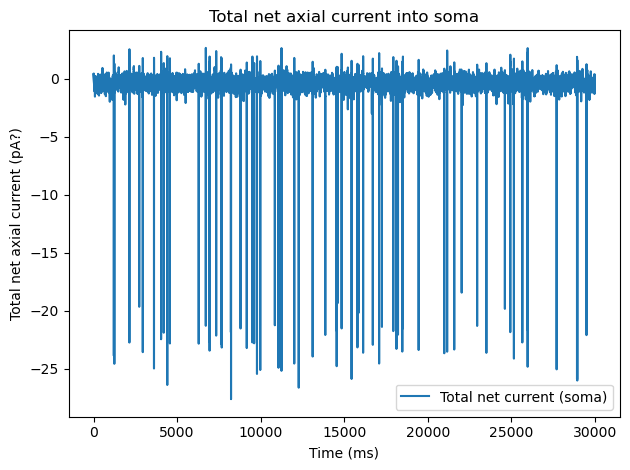

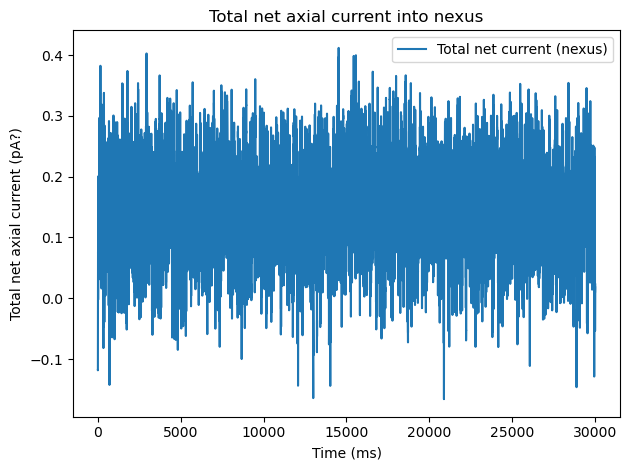

In [22]:
t = np.arange(0, parameters.h_tstop + parameters.h_dt, parameters.h_dt)
t = t[100:]

for seg_interest_type, seg_interest_data in segments_of_interest.items():
    plt.figure()
    plt.title(f"Total net axial current into {seg_interest_type}")

    # Extract currents, default to empty arrays
    asc_currs = np.array(seg_interest_data.get('ascendant_currents', []))
    desc_currs = np.array(seg_interest_data.get('descendant_currents', []))

    # Handle single-segment case
    if asc_currs.size > 0 and asc_currs.ndim == 1:
        asc_currs = asc_currs[np.newaxis, :]
    if desc_currs.size > 0 and desc_currs.ndim == 1:
        desc_currs = desc_currs[np.newaxis, :]

    # Determine n_seg, n_times
    if asc_currs.size > 0:
        n_seg, n_times = asc_currs.shape
    elif desc_currs.size > 0:
        n_seg, n_times = desc_currs.shape
    else:
        print(f"No currents found for {seg_interest_type}, skipping.")
        continue

    # Fill empty with zeros
    if asc_currs.size == 0:
        asc_currs = np.zeros((n_seg, n_times))
    if desc_currs.size == 0:
        desc_currs = np.zeros((n_seg, n_times))

    # Compute net current for each segment, then sum over all segments
    net_current = np.sum(asc_currs + desc_currs, axis=0)[100:]

    plt.plot(t, net_current, label=f'Total net current ({seg_interest_type})')
    # plt.ylim([-2,2])
    plt.xlabel('Time (ms)')
    plt.ylabel('Total net axial current (pA?)')
    plt.legend()
    plt.tight_layout()
    plt.show()



In [23]:
np.shape(seg_interest_data[f'{relative_type}_ids'])

(2,)

In [25]:
# seg_interest_data[f'{relative_type}_ids'][indices_to_sum]

In [26]:
relative_type

'descendant'

In [27]:
v[0,47000]

-57.48506789444914

In [28]:
v[segments_of_interest['soma']['descendant_ids'][-2],47000]

-57.46856894294702

In [29]:
segments_of_interest['soma']['descendant_ids'][-2]

1070

['L5PCtemplate[0].apic[0](0.05)' 'L5PCtemplate[0].axon[0](0.0384615)']


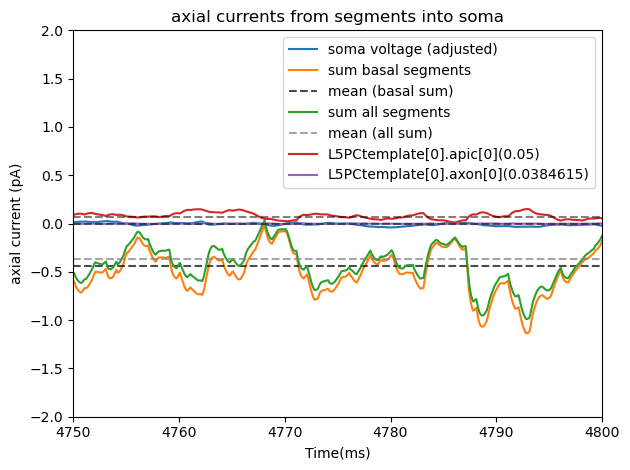

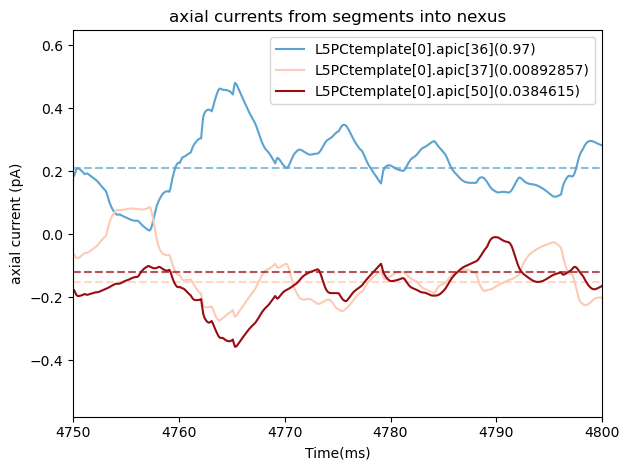

In [37]:
import numpy as np
import matplotlib.pyplot as plt

sum_basal_for_soma = True

t = np.arange(0, parameters.h_tstop+parameters.h_dt, parameters.h_dt)
t = t[100:]
for seg_interest_type, seg_interest_data in segments_of_interest.items():
    is_soma = seg_interest_type == 'soma'
    plt.figure()
    plt.title(f"axial currents from segments into {seg_interest_type}")
    for relative_type in ['ascendant', 'descendant']:
        cmap = plt.cm.Blues if relative_type == 'ascendant' else plt.cm.Reds
        num_segments = len(seg_interest_data[f'{relative_type}_ids'])
        fractions = np.linspace(0.2, 0.9, num_segments) if num_segments > 1 else [0.55]

        if sum_basal_for_soma and is_soma:
            if not seg_interest_data[f'{relative_type}_names'] == []:
                plt.plot(t, (v[0,100:]/70) - np.mean(v[0,100:]/70), label='soma voltage (adjusted)')
                indices_to_sum = np.array(['dend' in item for item in seg_interest_data[f'{relative_type}_names']])
                if not 0 in np.shape(indices_to_sum):
                    summed_basal = sum(np.array(seg_interest_data[f'{relative_type}_currents'])[indices_to_sum])[100:]
                    summed_all = sum(np.array(seg_interest_data[f'{relative_type}_currents'])[:])[100:]
                    plt.plot(t, summed_basal, label='sum basal segments')
                    # Dashed mean for summed basal
                    plt.axhline(np.mean(summed_basal), color='k', linestyle='--', alpha=0.7, label='mean (basal sum)')
                    plt.plot(t, summed_all, label='sum all segments')
                    # Dashed mean for summed all
                    plt.axhline(np.mean(summed_all), color='gray', linestyle='--', alpha=0.7, label='mean (all sum)')
                print(np.array(seg_interest_data[f'{relative_type}_names'])[~indices_to_sum])
                for i, seg_id in enumerate(np.array(seg_interest_data[f'{relative_type}_ids'])):
                    if ~indices_to_sum[i]:
                        current_trace = seg_interest_data[f'{relative_type}_currents'][i][100:]
                        label = np.array(seg_interest_data[f'{relative_type}_names'])[i]
                        plt.plot(t, current_trace, label=label)
                        # Dashed mean for each trace
                        plt.axhline(np.mean(current_trace), color='k', linestyle='--', alpha=0.5)
                plt.ylim([-2, 2])
        else:
            for i, seg_id in enumerate(seg_interest_data[f'{relative_type}_ids']):
                color = cmap(fractions[i])
                current_trace = seg_interest_data[f'{relative_type}_currents'][i][100:]
                label = seg_interest_data[f'{relative_type}_names'][i]
                if is_soma:
                    plt.plot(t, current_trace, label=label)
                    plt.ylim([-2, 2])
                else:
                    plt.plot(t, current_trace, label=label, color=color)
                # Dashed mean for each trace
                plt.axhline(np.mean(current_trace), color=color, linestyle='--', alpha=0.7)
    plt.xlim(4750, 4800)
    plt.xlabel('Time(ms)')
    plt.ylabel('axial current (pA)')
    plt.legend()
    plt.tight_layout()
    plt.show()


General Notes to know: 

positive is into the segment
negative is out of the segment

positive is from other segment to nexus/soma
negative is from nexus/soma to other segment

red is segments away from the soma, 
blue is segments toward the soma

Soma AC:

Charge is usually flowing from apical trunk into soma into basal dendrites.

Axon doesn't matter.

Nexus AC:

Charge is usually flowing from distal toward soma

Additional Notes:

Can also plot segment currents

## Plot Channel Currents

In [32]:
currents = {
    # 'ica_hva': analysis.DataReader.read_data(sim_dir, 'ica_Ca_HVA'),
    # 'ica_lva': analysis.DataReader.read_data(sim_dir, 'ica_Ca_LVAst'),
    # 'ik': analysis.DataReader.read_data(sim_dir, 'ik_Im'),
    'ica': analysis.DataReader.read_data(sim_dir, 'ica'),
    'Vm': analysis.DataReader.read_data(sim_dir, 'v')
}

In [33]:
for current_name, current in currents.items():
    print(f"{current_name} shape: {current.shape}")

ica shape: (2630, 300001)
Vm shape: (2630, 300001)


In [ ]:
# for current_name, current in currents.items():
#     print(f"{current_name} sum over time:")
#     print(np.sum(current, axis=1))
#     valid_rows = ~np.isnan(current).any(axis=1)  # Identify rows without NaN values
#     filtered_current = current[valid_rows]  # Filter out rows with NaN values
#     summed_current = np.sum(filtered_current, axis=0)  # Sum over time for valid rows
#     print(summed_current)
#     plt.plot(summed_current)
#     plt.title(f"{current_name} sum all segments")
#     plt.xlabel("Timesteps")
#     plt.show()

In [34]:
def plot_in_increments(var, var_name, params, simulation_dir, increment=5000, save = False):
    # plot ever increment ms separately
    # increment in ms since dt, h_tstop, and time are in ms
    # default 5000 ms
    increment_start= 0
    increment_end = increment
    time = np.arange(0,params.h_tstop+params.h_dt,params.h_dt)
    indices_to_plot = time < increment_end
    # while max(times_to_plot) < params.h_tstop+params.h_dt:
    while sum(indices_to_plot) > 1:
        plt.plot(time[indices_to_plot],var[indices_to_plot])
        plt.xlabel('Time (ms)')
        plt.ylabel(var_name)
        plt.show()

        if save:
            plt.savefig(os.path.join(simulation_dir,var_name,f"{var_name}_{increment_start}to{increment_end}"))

        # update indices_to_plot by increment
        increment_end = increment_start+increment
        indices_to_plot = np.logical_and(time <= increment_end, time >= increment_start)
        increment_start = increment_end

# # Plot
# for current_name, current in currents.items():
#     print(f"{current_name} sum over time:")
#     print(np.sum(current, axis=1))
#     valid_rows = ~np.isnan(current).any(axis=1)  # Identify rows without NaN values
#     filtered_current = current[valid_rows]  # Filter out rows with NaN values
#     summed_current = np.sum(filtered_current, axis=0)  # Sum over time for valid rows
#     # plot_in_increments(summed_current, f"{current_name} summed across segments", parameters, increment=5000)
#     # print(summed_current)
#     plt.plot(summed_current)
#     plt.title(f"{current_name} sum all segments")
#     plt.xlabel("Timesteps")
#     plt.show()

Now do for segments of interest

In [35]:
segments_of_interest

{'soma': {'seg_index': 0,
  'descendant_ids': array([   1,  128,  231,  476,  523,  770, 1005, 1014, 1070, 2617]),
  'descendant_names': ['L5PCtemplate[0].dend[0](0.1)',
   'L5PCtemplate[0].dend[7](0.0833333)',
   'L5PCtemplate[0].dend[16](0.166667)',
   'L5PCtemplate[0].dend[39](0.025)',
   'L5PCtemplate[0].dend[42](0.125)',
   'L5PCtemplate[0].dend[63](0.1)',
   'L5PCtemplate[0].dend[78](0.0555556)',
   'L5PCtemplate[0].dend[79](0.125)',
   'L5PCtemplate[0].apic[0](0.05)',
   'L5PCtemplate[0].axon[0](0.0384615)'],
  'ascendant_ids': array([], dtype=int64),
  'ascendant_names': [],
  'ascendant_currents': [],
  'descendant_currents': [array([-0.        ,  0.00022765, -0.00112276, ..., -0.00158553,
           0.00330268,  0.0069605 ]),
   array([-0.00000000e+00,  3.57121805e-04, -1.76089305e-03, ...,
          -6.17277642e-01, -6.17112724e-01, -6.12992037e-01]),
   array([-0.        ,  0.00029452, -0.00092136, ...,  0.01738133,
           0.01439715,  0.01260701]),
   array([-0.0000000

ica for soma:


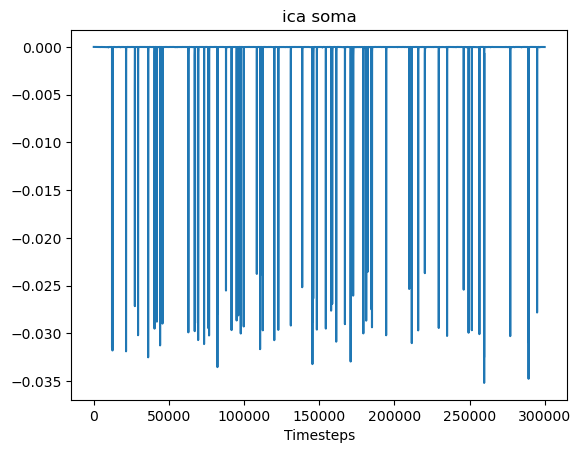

Vm for soma:


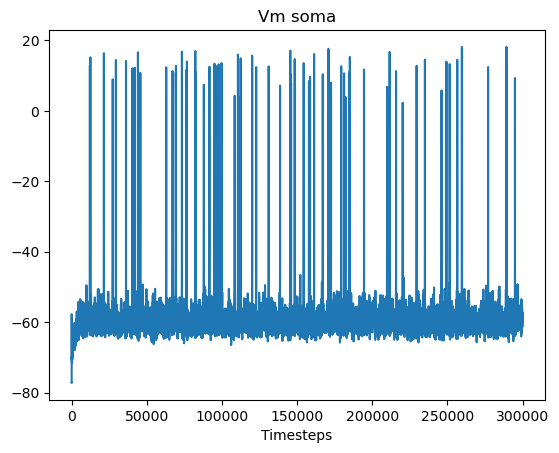

ica for nexus:


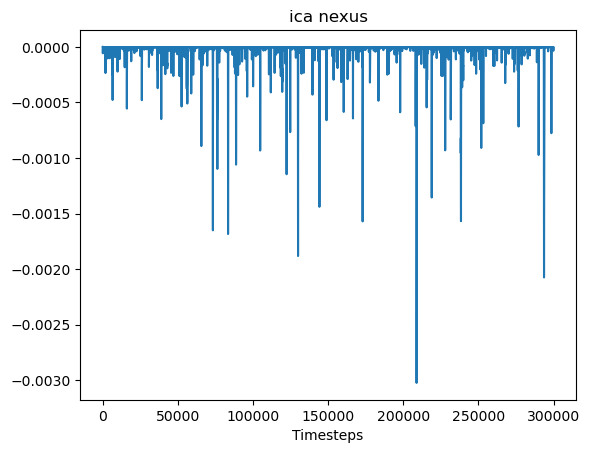

Vm for nexus:


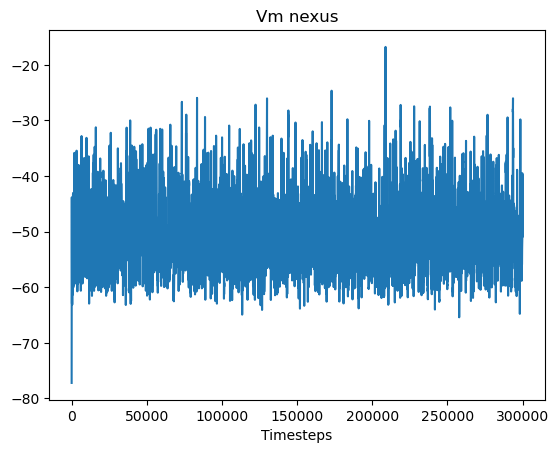

In [36]:
for seg_name, seg_info in segments_of_interest.items():
    for current_name, current in currents.items():
        print(f"{current_name} for {seg_name}:")
        current_to_plot = current[seg_info['seg_index'],:]
        # plot_in_increments(current_to_plot, f"{current_name} {seg_name}", parameters, increment=5000)

        plt.plot(current_to_plot)
        plt.title(f"{current_name} {seg_name}")
        plt.xlabel("Timesteps")
        plt.show()